# Classer avec la méthode des k-Plus Proches Voisins

Dans ce TP nous allons implémenter notre première Intelligence Artificielle à partir de la méthode des k-Plus Proches Voisins étudiée en TD. Nous allons implémenter, tester, évaluer et étudier cette méthode de classification sur un jeu de données réelles.

## A. Charger, explorer puis préparer le tableau de données

Commencez par importer dans un Dataframe `zoo` les données du fichier `zoo.csv`.

In [3]:
import numpy  as np
import pandas as pd
zoo = pd.read_csv('donnees/zoo.csv')  # paramétrage par défaut
zoo

,Name,hair,feathers,eggs,milk,airbone,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,size,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,115.0,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,75.0,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,40.0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,210.0,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,120.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,wallaby,1,0,0,1,0,0,0,1,1,1,0,0,2,1,0,105.0,1
96,wasp,1,0,1,0,1,0,0,0,0,1,1,0,6,0,0,0.9,6
97,wolf,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,75.0,1
98,worm,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,35.0,7


Explorez le dataset `zoo`: Combien d'individus? Combien de descripteurs? Quelle est la nature (type) des descripteurs? Y-a-t'il des valeurs manquantes?

In [4]:
zoo.describe

<bound method NDFrame.describe of         Name  hair  feathers  eggs  milk  airbone  aquatic  predator  toothed  \
0   aardvark     1         0     0     1        0        0         1        1   
1   antelope     1         0     0     1        0        0         0        1   
2       bass     0         0     1     0        0        1         1        1   
3       bear     1         0     0     1        0        0         1        1   
4       boar     1         0     0     1        0        0         1        1   
..       ...   ...       ...   ...   ...      ...      ...       ...      ...   
95   wallaby     1         0     0     1        0        0         0        1   
96      wasp     1         0     1     0        1        0         0        0   
97      wolf     1         0     0     1        0        0         1        1   
98      worm     0         0     1     0        0        0         0        0   
99      wren     0         1     1     0        1        0         0       

Dans ce dataset, la dernière colonne `type` correspond à la catégorie de l'animal :
|  Type  |    Catégorie    |
| :---------:|---------|
| 1 |Mammifères|
| 2 |Oiseaux|
| 3 |Reptiles|
| 4 |Poissons|
| 5 |Amphibiens|
| 6 |Insectes|
| 7 |Invertébrés|

Notre IA devra prédire la catégorie d'un animal à partir de sa description (sans le `Name`). Il s'agit donc d'une tâche de prédiction à **7 classes**.

Observez la distribution des individus selon la variable de classe (`type`) et constatez le déséquilibre des classes. Cela aura-t'il une incidence sur la méthode de k-PPV?

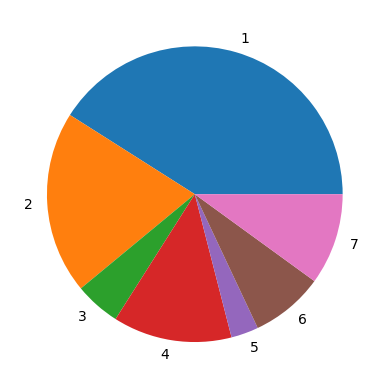

In [12]:
import matplotlib.pyplot as plt
labels, sizes = np.unique(zoo['type'], return_counts=True)
plt.pie(sizes, labels=labels)
plt.show()

A partir du dataframe `zoo`, vous allez construire deux tableaux Numpy :
- `X` est la matrice (100x16) des descriptions des individus
- `y` est le vecteur contenant les (100) catégories d'animaux 

In [13]:
X= np.array(zoo.iloc[:, 1:-1])
y= np.array(zoo['type'])
print(y)

[1 1 4 1 1 1 1 4 4 1 1 2 4 7 7 7 2 1 4 1 2 2 1 2 6 5 1 1 1 6 1 1 2 4 1 1 2
 4 6 6 2 6 2 1 1 7 1 1 1 1 6 5 7 1 1 2 2 2 2 4 4 3 1 1 1 1 1 1 1 1 2 7 4 1
 1 3 7 2 2 3 7 4 2 1 7 4 2 6 5 3 3 4 1 1 2 1 6 1 7 2]


Nous allons à présent découper `X` et `y` en deux sous-ensembles :
- `X_train` : qui contient des individus que la méthode k-PPV utilisera pour prédire
- `X_test`  : qui contient des individus que nous utiliserons pour évaluer notre IA (et ainsi ajuster le paramètre k)
- `y_train` : qui contient les labels des individus de `X_train`
- `y_test`  : qui contient les labels des individus de `X_test`

Ecrire une fonction (générique) `train_test_split(X, y, train_ratio)` qui réalise un tel découpage :

In [14]:
def train_test_split(X, y, train_ratio):
    """découpe
    nsi que les labels associés

    Args:
        X (matrice Numpy): le dataset à découper
        y (vecteur Numpy): le vecteur des labels à découper
        train_ratio (float): entre 0.0 et 1.0 = proportion du dataset à inclure dans l'ensemble d'entraînement (train)

    Returns:
        X_train (matrice Numpy): le sous-ensemble d'entraînement
        X_test (matrice Numpy):  le sous-ensemble de test
        y_train (vecteur Numpy): les labels données d'entraînement
        y_test (vecteur Numpy):  les labels données de test

    """
    N= X.shape[0]
    if y.shape[0] !=N:
        return None
    
    ids = np.arange(N)
    np.random.shuffle(ids)
    nb_train = int(N*train_ratio)
    train_ids, test_id = ids[:nb_train], ids[nb_train:]

    return X[train_ids, :], X[test_id, :], y[train_ids], y[test_id]

    
    

Utilisez votre fonction pour découper notre dataset `X` en deux sous-ensembles de mêmes tailles.

Vérifiez que les déséquilibres des classes sont globalement respectés (relancez le découpage si certaines classes sont absentes dans l'un des deux sous-ensembles).

In [15]:
x_train, x_test, y_train, y_test= train_test_split(X, y, 0.7)
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

#np.unique => combien de fois on a valeur unique exemple 5 fois la valeur 1

(array([1, 2, 3, 4, 5, 6, 7]), array([27, 13,  3, 11,  3,  6,  7]))
(array([1, 2, 3, 4, 6, 7]), array([14,  7,  2,  2,  2,  3]))


---

## B. Implémenter et évaluer la méthode k-PPV (non-pondérée)

Définissez une fonction `predict_kNN(k, X, y, x_new)` qui prédit la classe d'une description `x_new` par la méthodes k-PPV non-pondérée utilisée sur les données `X` de ayant pour labels `y` avec la distance Euclidienne.

In [16]:
def predict_kNN(k, X, y, x_new):
    """implémente le classifieur du k-Plus Proches Voisins 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X (matrice Numpy): le dataset des données d'entraînement
        y (vecteur Numpy): le vecteur des labels des données d'entraînement
        x_new (vecteur Numpy) : le vecteur de description d'une nouvelle donnée à classer

    Returns:
        y_new (label):  le label prédit

    """
    distances= np.linalg.norm(X- x_new, axis = 1)
    ppv_id = distances.argsort()[:k] #ppv = plus proche voisin
    ppv_class = y[ppv_id]
    y_new, count = np.unique (ppv_class, return_counts= True)
    return y_new[count.argsort()[-1]]




Utilisez la fonction `predict_kNN` pour prédire la classe de l'individu situé à l'indice 23 dans `X_test` à partir des données d'entraînement (`X_train`, `y_train`). Affichez la classe prédite selon différentes valeurs de `k` et comparez avec la vraie classe de l'individu (`y_test[23]`). 

In [18]:
i=23
print([predict_kNN(k, x_train, y_train, x_test[i, :] ) for k in range (1,20)])
y_test[i]

[1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 7, 7, 7, 7, 2, 2, 2, 2]


1

Définissez une fonction `error_kNN(k, X_train, y_train, X_test, y_test)` qui renvoie le taux d'erreur de prédiction de la méthode k-PPV sur des données de test. 

In [19]:
def error_kNN(k, X_train, y_train, X_test, y_test,):
    """calcule le taux d'erreur de prédiction par k-PPV sur les données de test 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X_train (matrice Numpy): le dataset des données d'entraînement
        y_train (vecteur Numpy): le vecteur des labels des données d'entraînement
        X_test (vecteur Numpy) : le dataset des données de test
        y_test (vecteur Numpy): le vecteur des labels des données de test


    Returns:
        error_rate (float):  le taux d'erreur de prédiciton (Nb. mauvaises prédictions / Nb. prédictions)

    """
    prediction = [predict_kNN(k, X_train, y_train, X_test[i,:]) for i in range (y_test.size)]
    return 1 -sum(prediction == y_test)/y_test.size #nb de bonne rep sur nb 

Tracez la courbe du taux d'erreur en fonction du paramètre `k`. Quelle valeur choisirez-vous pour `k`? Est-ce que votre classifieur vous semble performant?

[0.5, 0.6, 0.6666666666666667, 0.6333333333333333, 0.5666666666666667, 0.5333333333333333, 0.5666666666666667, 0.6, 0.6, 0.5666666666666667, 0.5333333333333333, 0.5333333333333333, 0.5666666666666667, 0.5666666666666667, 0.5333333333333333, 0.5333333333333333, 0.5333333333333333, 0.5333333333333333, 0.5, 0.5]


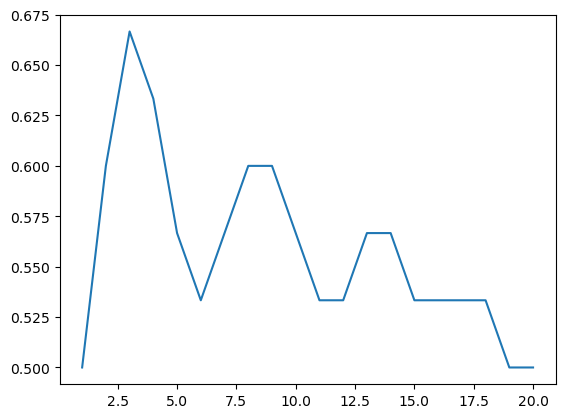

In [20]:
error = [error_kNN(k, x_train, y_train, x_test, y_test) for k in range(1,21)]
plt.plot(range(1,21), error)
print(error) 

#en se basant su graph on chosi modele (k) avec erreur la plus petite

Avant de conclure (trop vite!)... quel serait le taux d'erreur d'un classifieur k-PPV qui fonderait ses prédictions sur la taille des animaux uniquement (descripteur `size`)?

In [21]:
error_bis = [error_kNN(k, x_train[:, -1].reshape(50,1), y_train, x_test[:,-1].reshape(50,1), y_test) for k in range(1,21)]
plt.plot(range(1,21), error, label = "Error rate 16 description")
plt.plot(range(1,21), error_bis, label = "Error rate 1 description")
plt.legend()
plt.show()

ValueError: cannot reshape array of size 70 into shape (50,1)

## C. Normaliser les données

Vous avez constaté que tous les descriteurs n'ont pas la même influence dans le calcul des distances entre individus, du fait de l'amplitude des valeurs associée à chaque descripteurs.

Pour faire en sorte que chaque descripteur ait la même influence dans le traitement du tableau de données, on procède à une **normalisation** des données. 

> Normaliser un ensemble $Z$ consiste à ramener toutes ses valeurs dans l'intervalle $[0,1]$ par l'opération : $$\tilde{z}_{i}=\frac{z_{i}-min_Z}{max_Z-min_Z}$$
>

Complétez la classe `Normalizer` ci-dessous qui définit un **outil** de normalisation d'un jeu de données. La normalisation d'un jeu de données procédera en deux temps :
- calcul des paramètres de la fonction de normalisation sur des données (méthode `.fit()`)
- application de la fonction de normalisation sur des données (méthode `.transform()`)

In [22]:
class Normalizer:
    
    min = None
    max = None
    
    def fit(self, X):
        """calcule les min et max de chaque colonne de X"""
        
        self.min = X.min(axis=0)
        self.max = X.max(axis =0)
    
    def transform(self, X):
        """renvoie X normalisé"""
        if self.min is not None and self.max is not None:
            return (X- self.min)/self.max-self.min
        

Appliquez la normalisation sur l'ensemble des individus (100 descriptions) puis comparez l'erreur faite par la méthode des k-PPV avant et après normalisation. Concluez sur l'utilité de cette étape de normalisation.

ValueError: x and y must have same first dimension, but have shapes (20,) and (19,)

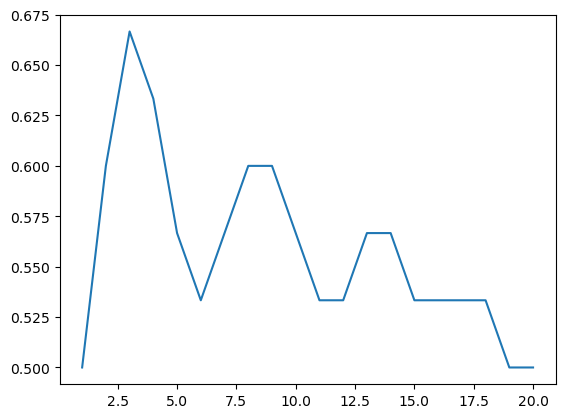

In [23]:
norm = Normalizer()
norm.fit (X)

#normalisation dataset
Xn_train = norm.transform(x_train)
Xn_test = norm.transform(x_test)


error_norm = [error_kNN(k,Xn_train, y_train, Xn_test, y_test) for k in range(1,20)]
plt.plot(range(1,21), error, label= "DOnnees brutes")
plt.plot(range(1,21), error_norm, label= "DOnnees normalise")

plt.legend()
plt.show()

## D. Implémenter et évaluer la méthode k-PPV pondérée

Implémentez la variante pondérée de la méthode k-PPV dans une version généralisée de la fonction `predict_kNN(k, X, y, x_new, weights)`

In [ ]:
def predict_kNN(k, X, y, x_new, weights='uniform'):
    """implémente le classifieur du k-Plus Proches Voisins 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X (matrice Numpy): le dataset des données d'entraînement
        y (vecteur Numpy): le vecteur des labels des données d'entraînement
        x_new (vecteur Numpy) : le vecteur de description d'une nouvelle donnée à classer
        weights ('uniform', 'distance') : méthode de pondération utilisée pour la prédiction

    Returns:
        y_new (label):  le label prédit

    """
    distance = np.linalg.norm(X- x_new, axis=1)
    ppv_id = distance.argsort()[:k]
    ppv_class = y[ppv_id]
    if weights == "uniform":
        w= np.ones(k)
    elif weights == 'distance':
        w= 1/distance[ppv_id]
    count = np.bincount(ppv_class, weights=w)
    return count.argsort()[-1]


Généralisez également la fonction d'évaluation `error_kNN(k, X_train, y_train, X_test, y_test, weights)` avec l'argument supplémentaire `weights`

In [ ]:
def error_kNN(k, X_train, y_train, X_test, y_test, weights='uniform'):
    """calcule le taux d'erreur de prédiction par k-PPV sur les données de test 

    Args:
        k (int): nombre de voisins à utiliser pour prédire
        X_train (matrice Numpy): le dataset des données d'entraînement
        y_train (vecteur Numpy): le vecteur des labels des données d'entraînement
        X_test (vecteur Numpy) : le dataset des données de test
        y_test (vecteur Numpy): le vecteur des labels des données de test
        weights ('uniform', 'distance') : méthode de pondération utilisée dans k-PPV


    Returns:
        error_rate (float):  le taux d'erreur de prédiciton (Nb. mauvaises prédictions / Nb. prédictions)

    """
    prediction = [predict_kNN(k, X_train, y_train, X_test[i,:], weights=weights) for i in range (y_test.size)]
    return 1 -sum(prediction == y_test)/y_test.size #nb de bonne rep sur nb 

Enfin, comparez l'erreur faite par chacune des deux versions de la méthode k-PPV (pondérée ou non).

In [ ]:
error_uniform= 